In [1]:
import sys
sys.path.append('..')

In [ ]:
import copy
import pandas as pd
import torch

from utils import show_audios
from src.training_and_inference.training_utils import load_dasheng, load_wav2vec2

# 

# Train loop

In [3]:
import yaml

from transformers import TrainingArguments

from src.training_and_inference.trainer import DenoiserTrainer
from src.training_and_inference.training_utils import load_vn_speech_transcript_datasets

In [4]:
model = load_dasheng()

Loading weights:   0%|          | 0/276 [00:00<?, ?it/s]

## Config

In [5]:
with open("../config.yaml") as file:
    train_config = yaml.safe_load(file)
torch.manual_seed(train_config['seed'])

In [6]:
datasets = load_vn_speech_transcript_datasets(
    train_config['target_sr'],
    train_config['train-test-ratio'],
    torch.linspace(0, 20, 21),
    True,
    mos_sig_thres=3.5,
    train_batch_size=train_config['batch_size'],
    test_batch_size=train_config['test_batch_size'],
    seed=train_config['seed']
)

Kept 1186 rows from fosd


Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/23 [00:00<?, ?it/s]

Kept 2504 rows from vlsp


/home/cactr/Projects/denoise-vdt/notebooks/../src/training_and_inference/datasets/datasets.py:162: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._snr_levels = torch.tensor(snr_levels)
/home/cactr/Projects/denoise-vdt/notebooks/../src/training_and_inference/datasets/datasets.py:162: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._snr_levels = torch.tensor(snr_levels)


## Downstream

In [ ]:
from src.training_and_inference.nlp_utils import preprocess_vn_text
from torchmetrics.functional.text import word_error_rate

model = model.to('cuda')
backbone = model.backbone.eval()
istft_head = model.head.eval()

processor, stt_model, compute_ctc_loss = load_wav2vec2()
stt_model = stt_model.eval().cuda()

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

In [ ]:
transcripts = [j for i in datasets['test']['loader'] for j in i[-1]]
prev_preds = None

def decode_embeddings(embeddings):
    return istft_head(backbone(embeddings))

def compute_metrics(eval_preds):
    global prev_preds
    prev_preds = eval_preds
    preds = [
        processor.batch_decode(torch.argmax(stt_model(
            processor(wf[:lens], sampling_rate=16000, return_tensors="pt").input_values.cuda()
        ).logits, dim=-1))[0]
        for wf, lens in zip(eval_preds.predictions, eval_preds.label_ids)
    ]

    return {
        'wer': word_error_rate(
            preprocess_vn_text(preds),
            preprocess_vn_text(transcripts)
        ),
    }

/home/cactr/Projects/denoise-vdt/.venv/lib/python3.14/site-packages/torch/nested/__init__.py:256: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  return _nested.nested_tensor(


## Trainer

In [11]:
training_args = TrainingArguments(**train_config['trainer-args'])

trainer = DenoiserTrainer(
    model.feature_extractor.cuda(),
    datasets['train']['loader'], datasets['test']['loader'],
    audio_decoder=decode_embeddings,
    # downstream_loss_fn=compute_ctc_loss,
    # downstream_loss_factor=.01,
    compute_metrics=compute_metrics,
    model_init=lambda: copy.deepcopy(model.second_encoder),
    args=training_args,
    eval_dataset=datasets['test']['speech_dataset']  # just so we can set eval_strategy
)

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


In [12]:
train_output = trainer.train(
    resume_from_checkpoint="best-2a/checkpoint-12300"
)

Epoch,Training Loss,Validation Loss,Wer
101,0.037126,0.040152,0.274026
102,0.038187,0.040317,0.280804
103,0.037686,0.039510,0.275003
104,0.036084,0.039188,0.275247
105,0.035794,0.038668,0.273416
106,0.036654,0.038764,0.277690
107,0.036341,0.038274,0.273477
108,0.035822,0.038071,0.272744
109,0.035505,0.038000,0.272317
110,0.036390,0.037985,0.272072


In [ ]:
import pickle

with open(f"{train_config['trainer-args']['output_dir']}/test-loader.pkl", 'wb') as file:
    pickle.dump(datasets['test']['loader']._cache, file)

# Inference

In [ ]:
import pickle
import matplotlib.pyplot as plt

from chunkformer import ChunkFormerModel
from torchmetrics.functional import (
    audio as func_audio,
    text as func_text
)

from utils import draw_spec
from src.training_and_inference.nlp_utils import preprocess_vn_text

from tqdm.notebook import tqdm
from IPython.display import display


device = 'cuda'

In [4]:
def compute_metrics(signals, sr):
    return {
        "dnsmos": func_audio.deep_noise_suppression_mean_opinion_score(
            signals, sr, False, device='cuda'
        ),
        "nisqa": func_audio.non_intrusive_speech_quality_assessment(signals, sr)
    }

def compute_wer(preds, targets):
    return func_text.word_error_rate(preprocess_vn_text(preds), preprocess_vn_text(targets))

## Load checkpoints

In [5]:
with open('best/test-loader.pkl', 'rb') as file:
    test_loader = pickle.load(file)

In [ ]:
model = load_dasheng(
    # "best/checkpoint-6150/model.safetensors"
    # "best/checkpoint-9963/model.safetensors"
    # "best/checkpoint-15621/model.safetensors"
).eval().to(device)

Loading weights:   0%|          | 0/276 [00:00<?, ?it/s]

In [ ]:
processor, stt_model = load_wav2vec2(
    "khanhld/wav2vec2-base-vietnamese-160h",
    freeze_model=False,
    return_loss_fn=False
)
stt_model = stt_model.eval().to(device)

def wav2vec2_transcribe(wav):
    input_values = processor(wav, sampling_rate=16000, return_tensors="pt").input_values
    logits = stt_model(input_values.to(device)).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return processor.batch_decode(pred_ids)

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

## Inference

### Chunkformer

In [ ]:
chunkformer = ChunkFormerModel.from_pretrained(
    "khanhld/chunkformer-ctc-large-vie"
).to(device)

def chunkformer_transcribe(audio_file):
    return chunkformer.endless_decode(
        audio_path=audio_file,
        return_timestamps=False
    )

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

In [19]:
transcriptions = {
    # "original": [],
    # "noisy": [],
    # "denoised-baseline": [],
    "denoised-6150": [],
    # "denoised-9963": [],
    # "denoised-15621": [],
    "target": [],
}
root = "test-audio"
i = 0
for *_, transcripts in tqdm(test_loader):
    transcriptions['target'].extend(transcripts)
    for transcript in transcripts:
        for audio_type in transcriptions.keys():
            if audio_type == "target":
                continue
            transcriptions[audio_type].append(
                chunkformer_transcribe(f"{root}/{audio_type}/{i:0>3}.wav")
            )
        i += 1

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


In [20]:
[
    # compute_wer(transcriptions['original'], transcriptions['target']),
    # compute_wer(transcriptions['noisy'], transcriptions['target']),
    # compute_wer(transcriptions['denoised-baseline'], transcriptions['target']),
    compute_wer(transcriptions['denoised-6150'], transcriptions['target']),
    # compute_wer(transcriptions['denoised-9963'], transcriptions['target']),
    # compute_wer(transcriptions['denoised-15621'], transcriptions['target']),
]

[tensor(0.0294)]

### Wav2Vec2

In [8]:
def show_denoise_res(
    idx,
    results,
    sr=16000,
):
    originals = [(results['original'][idx], sr, 'Original')]

    noise_mask = results['noises']['mask']
    rir_mask = (noise_mask == 0) | (noise_mask == 2)
    snr_mask = (noise_mask == 1) | (noise_mask == 2)
    rir_indices = torch.cumsum(rir_mask.long(), dim=0) - 1
    snr_indices = torch.cumsum(snr_mask.long(), dim=0) - 1

    indicator = noise_mask[idx]
    augment_type = []
    if indicator in (0, 2):
        augment_type.append("RIR")
        originals.append((results['noises']['rir'][rir_indices[idx]], sr, 'RIR'))
    if indicator in (1, 2):
        augment_type.append("SNR")
        originals.append((results['noises']['snr'][snr_indices[idx]], sr, 'SNR'))

    audio_widgets = show_audios([
        originals,
        [
            (results['noisy'][idx], sr, 'Noisy'),
            (results['denoised'][idx], sr, 'Denoised'),
        ],
    ])

    target_trans = results['transcripts']['target'][idx]
    orig_trans = results['transcripts']['original'][idx]
    noisy_trans = results['transcripts']['noisy'][idx]
    denoised_trans = results['transcripts']['denoised'][idx]
    local_wers = {
        'original': compute_wer([orig_trans], [target_trans]),
        'noisy': compute_wer([noisy_trans], [target_trans]),
        'denoised': compute_wer([denoised_trans], [target_trans]),
    }

    print("Augmentation type:", ', '.join(augment_type))
    display(audio_widgets)
    print(f"""
\033[1mTarget Transcript\033[0m:
    {target_trans}

\033[1mOriginal Transcript\033[0m: {local_wers['original']:.2%}
    {orig_trans}

\033[1mNoisy Transcript\033[0m: {local_wers['noisy']:.2%}
    {noisy_trans}

\033[1mDenoised Transcript\033[0m: {local_wers['denoised']:.2%}
    {denoised_trans}
""")

In [ ]:
transcribe = wav2vec2_transcribe
results = {
    "original": [],
    "noisy": [],
    "denoised": [],
    "noises": {'snr': [], 'rir': [], 'mask': []},
    "transcripts": {"original": [], "noisy": [], "denoised": [], 'target': []},
}

for clean, noisy, noises, lengths, transcriptions in tqdm(test_loader):
    if 'snr' in noises:
        results['noises']['snr'].extend(noises['snr'])
    if 'rir' in noises:
        results['noises']['rir'].extend(noises['rir'])
    results['noises']['mask'].append(noises['noise_mask'])
    results['transcripts']['target'].extend(transcriptions)

    with torch.no_grad(), torch.autocast(device):
        denoised = model(clean.to(device)).cpu()

        for i, length in enumerate(lengths):
            results['original'].append(clean[i, :length])
            results['noisy'].append(noisy[i, :length])
            results['denoised'].append(denoised[i, :length])

            results['transcripts']['original'].extend(transcribe(clean[i, :length]))
            results['transcripts']['noisy'].extend(transcribe(noisy[i, :length]))
            results['transcripts']['denoised'].extend(transcribe(denoised[i, :length]))

results['noises']['mask'] =  torch.concat(results['noises']['mask'])

In [15]:
[
    compute_wer(results['transcripts']['original'], results['transcripts']['target']),
    compute_wer(results['transcripts']['noisy'], results['transcripts']['target']),
    compute_wer(results['transcripts']['denoised'], results['transcripts']['target']),
]

[tensor(0.9999), tensor(0.9999), tensor(1.)]

Augmentation type: RIR, SNR



Target Transcript:
    Mình quý nhà báo, quý bác sĩ quá đi thôi !

Original Transcript: 0.00%
    mình quý nhà báo quý bác sĩ quá đi thôi

Noisy Transcript: 62.50%
    đình quý nhà báo bị bác sĩ tán đị phương

Denoised Transcript: 0.00%
    mình quý nhà báo quý bác sĩ quá đi thôi



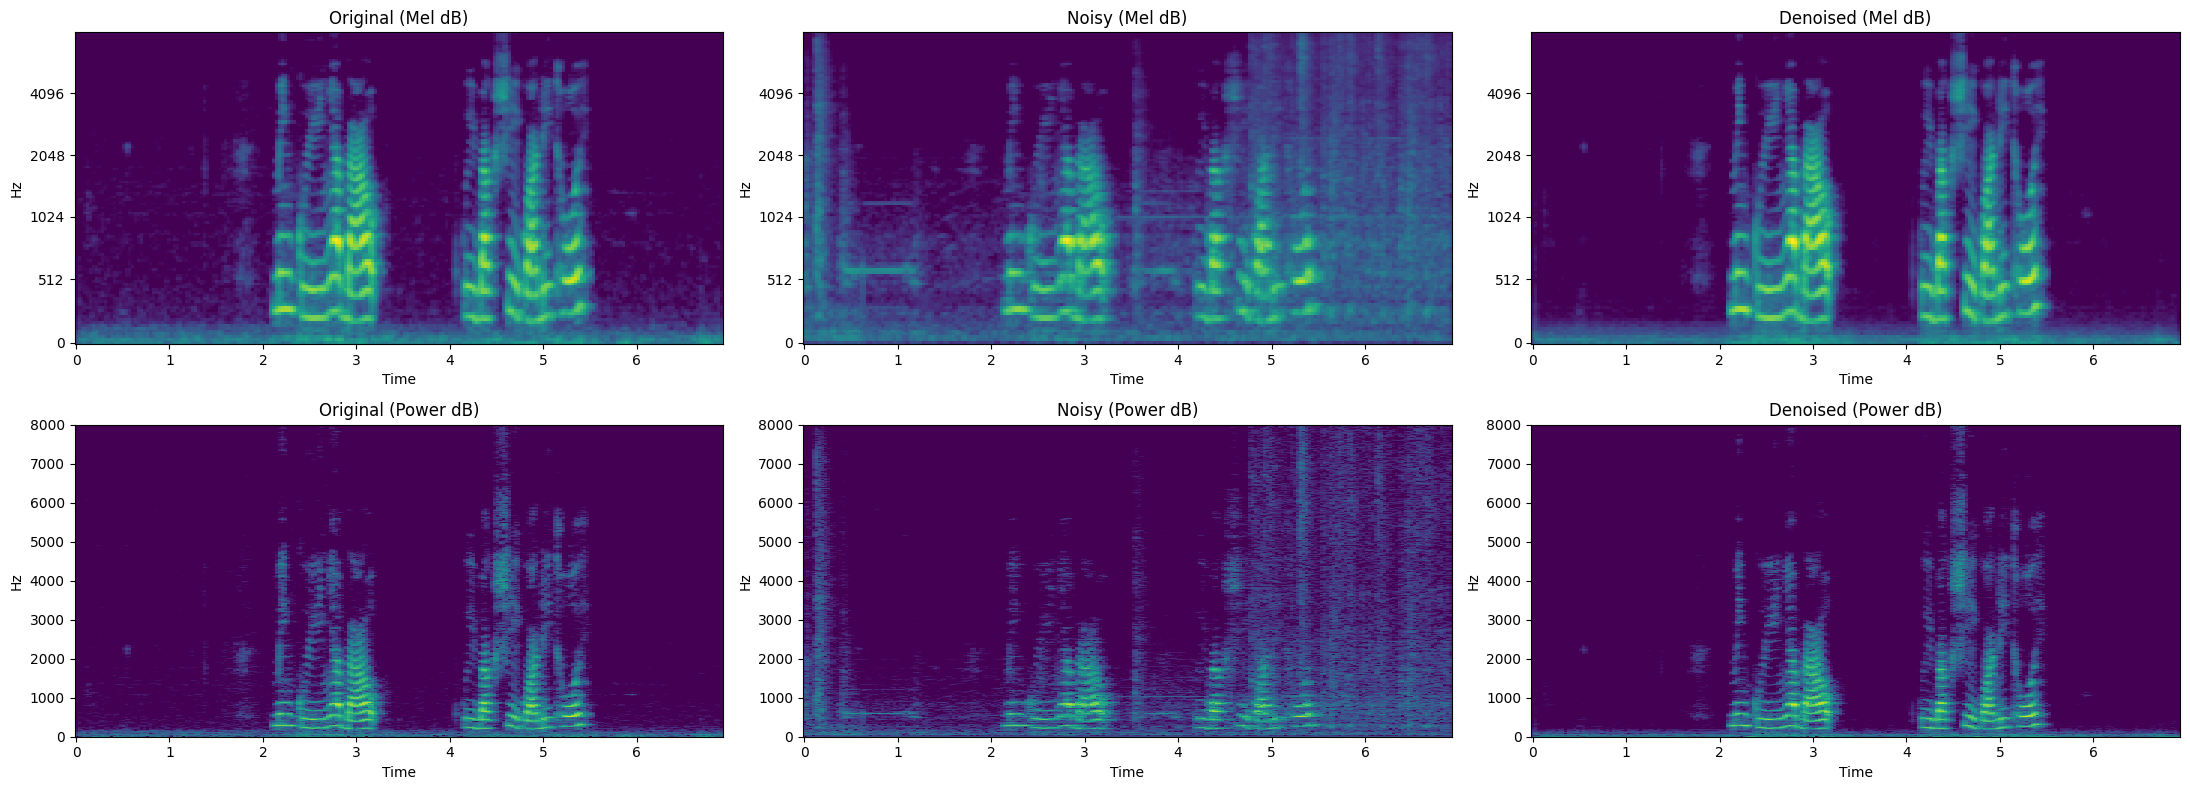

In [90]:
sr = 16000
idx = 3

show_denoise_res(idx, results, sr)

fig = plt.figure(figsize=(22, 8))
axes = fig.subplots(2, 3)

for i, key in enumerate(['original', 'noisy', 'denoised']):
    wf = results[key][idx].numpy()

    draw_spec(
        wf, sr,
        name=key.capitalize() + " (Mel dB)",
        ax=axes[0, i]
    )
    draw_spec(
        wf, sr,
        use_mel=False,
        name=key.capitalize() + " (Power dB)",
        ax=axes[1, i]
    )

# fig.colorbar(format='%+2.0f dB')
fig.tight_layout()
plt.show()

In [13]:
from torchcodec.encoders import AudioEncoder

In [11]:
!mkdir test-audio/denoised-6150/

In [ ]:
for i, batch in enumerate(zip(results['original'], results['noisy'])):
    for name, samples in zip(['original', 'noisy'], batch):
        AudioEncoder(samples, sample_rate=16000).to_file(f"test-audio/{name}/{i:0>3}.wav")

In [14]:
for i, samples in enumerate(results['denoised']):
    AudioEncoder(samples, sample_rate=16000).to_file(f"test-audio/denoised-6150/{i:0>3}.wav")